# Dataset Preprocessing Pipeline

## Imports

Required libraries for data handling, image I/O, and TF pipelines.

In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


## Settings

Dataset CSV path, image size, and batch size constants.

In [2]:
DATASET_CSV = r"datasets/saved_datasets/dataset_split.csv"
IMG_SIZE    = (160, 160)   # model input size
BATCH_SIZE  = 32


## Load Dataset

Read the dataset split CSV into a DataFrame and preview it.

In [3]:
df = pd.read_csv(DATASET_CSV)

print("Total samples:", len(df))
print(df.head())


Total samples: 28025
                                                path       label  split
0  C:\Users\AmrAhmed\Desktop\Level 3\Second Term\...  non_drowsy  train
1  C:\Users\AmrAhmed\Desktop\Level 3\Second Term\...      drowsy  train
2  C:\Users\AmrAhmed\Desktop\Level 3\Second Term\...  non_drowsy  train
3  C:\Users\AmrAhmed\Desktop\Level 3\Second Term\...  non_drowsy  train
4  C:\Users\AmrAhmed\Desktop\Level 3\Second Term\...      drowsy  train


## Inspect Distribution

Show label counts and missing-value counts.

In [4]:
print(df["label"].value_counts())
print(df.isnull().sum())


label
drowsy        14323
non_drowsy    13702
Name: count, dtype: int64
path     0
label    0
split    0
dtype: int64


## Split Train and Test

Separate rows by the `split` column.

In [5]:
train_df = df[df["split"] == "train"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print(len(train_df), len(test_df))


22420 5605


## Encode Labels

Build a label-to-index map and apply it to both splits.

In [6]:
label_map = {label: idx for idx, label in enumerate(df["label"].unique())}  # str -> int

train_df["label_enc"] = train_df["label"].map(label_map)
test_df["label_enc"]  = test_df["label"].map(label_map)

print(label_map)


{'non_drowsy': 0, 'drowsy': 1}


## Image Loader

Open, resize, and normalize an image to `[0, 1]`.

In [7]:
def load_and_preprocess(path):
    img = Image.open(path).convert("RGB").resize(IMG_SIZE)
    img = np.array(img, dtype=np.float32) / 255.0   # scale to [0, 1]
    return img


## Augmentation Layers

Keras layers for flips, rotations, zoom, and contrast jitter.

In [22]:
augmentation_train = tf.keras.Sequential([   # used during training
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

augmentation_viz = tf.keras.Sequential([     # same layers, used for previews
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])


## Augmentation Preview

Plot original vs augmented samples side-by-side.

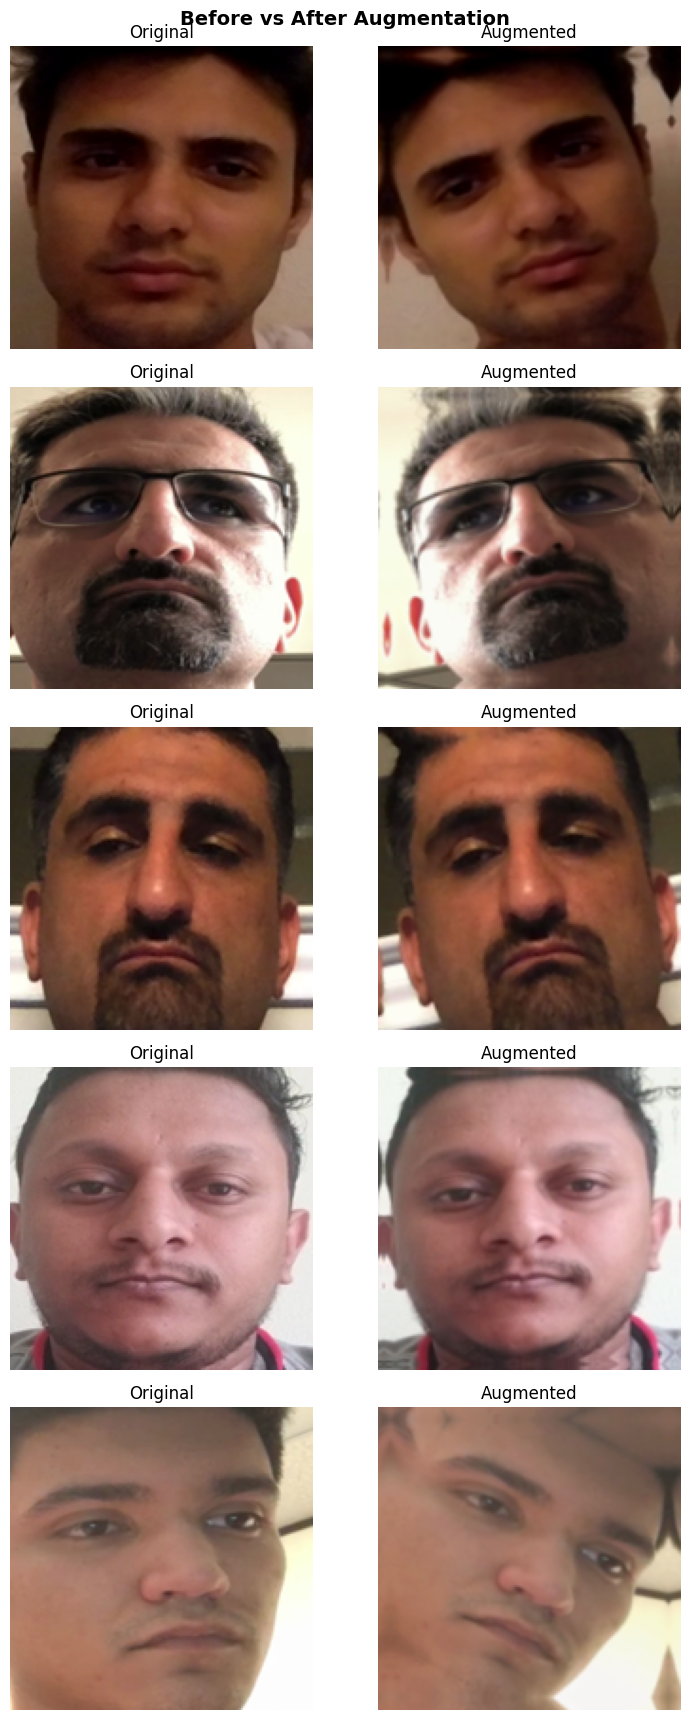

In [23]:
n = 5
sample = train_df.sample(n, random_state=42)

fig, axes = plt.subplots(n, 2, figsize=(8, 3.5 * n))
fig.suptitle("Before vs After Augmentation", fontsize=14, fontweight="bold")

for i, (_, row) in enumerate(sample.iterrows()):
    
    original = load_and_preprocess(row["path"])
    augmented = augmentation(tf.expand_dims(original, axis=0), training=True).numpy()[0]

    axes[i][0].imshow(original)
    axes[i][0].set_title("Original")
    axes[i][0].axis("off")

    axes[i][1].imshow(np.clip(augmented, 0, 1))
    axes[i][1].set_title("Augmented")
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()


## Map Functions

TF wrappers that load, augment (train only), and shape images.

In [30]:
def load_tf(path):
    if isinstance(path, bytes):
        path = path.decode("utf-8")
    else:
        path = path.numpy().decode("utf-8")
    return load_and_preprocess(path)

def train_map(path, label):
    img = tf.numpy_function(load_tf, [path], tf.float32)
    img.set_shape((*IMG_SIZE, 3))
    img = augmentation_train(img, training=True)   # augment train only
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def test_map(path, label):
    img = tf.numpy_function(load_tf, [path], tf.float32)
    img.set_shape((*IMG_SIZE, 3))
    img = tf.clip_by_value(img, 0.0, 1.0)          # no augmentation
    return img, label

    return img, label


## Build tf.data Pipelines

Train/test datasets with shuffle, batching, and prefetch.

In [31]:
train_dataset = (
    tf.data.Dataset.from_tensor_slices(
        (train_df["path"].values, train_df["label_enc"].values)
    )
    .shuffle(1000)                                  # shuffle each epoch
    .map(train_map, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)                     # overlap CPU + GPU work
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices(
        (test_df["path"].values, test_df["label_enc"].values)
    )
    .map(test_map, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


## Sanity Check

Print shape, value range, and labels of one batch from each set.

In [32]:
for images, labels in train_dataset.take(1):
    print("Train batch")
    print(f"  Shape  : {images.shape}")
    print(f"  Min    : {images.numpy().min():.4f}")
    print(f"  Max    : {images.numpy().max():.4f}")
    print(f"  Labels : {labels.numpy()}")

print()

for images, labels in test_dataset.take(1):
    print("Test batch")
    print(f"  Shape  : {images.shape}")
    print(f"  Min    : {images.numpy().min():.4f}")
    print(f"  Max    : {images.numpy().max():.4f}")
    print(f"  Labels : {labels.numpy()}")


Train batch
  Shape  : (32, 160, 160, 3)
  Min    : 0.0000
  Max    : 1.0000
  Labels : [1 0 0 1 1 0 1 0 1 1 1 1 1 1 0 0 1 0 0 0 0 1 1 1 0 1 0 0 0 1 0 1]

Test batch
  Shape  : (32, 160, 160, 3)
  Min    : 0.0000
  Max    : 1.0000
  Labels : [0 1 0 0 0 0 1 1 1 0 0 1 1 1 0 0 0 1 1 0 1 0 0 1 0 1 0 0 1 1 1 1]
